#Setup:

In [33]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay)

RANDOM_STATE = 42
plt.rcParams["figure.dpi"] = 110

In [10]:
# Load dataset — each row is a student, each column is a feature
df = pd.read_csv('student_performance.csv')
print(f'Dataset: {df.shape[0]} , {df.shape[1]} columns')
df.head(8)

Dataset: 500 , 9 columns


,student_id,study_hours_week,attendance_pct,prev_gpa,sleep_hours,assignments_done_pct,part_time_job,final_score,passed
0,S001,11.2,96.4,2.86,6.1,66.9,0,73.5,1
1,S002,5.8,90.7,2.46,6.1,63.0,0,52.9,0
2,S003,13.0,71.4,2.65,8.4,82.8,0,74.2,1
3,S004,13.8,62.0,3.28,7.2,79.5,0,68.2,1
4,S005,2.2,44.4,2.90,6.5,49.7,0,39.9,0
5,S006,4.8,73.5,3.10,7.4,95.2,1,53.8,0
6,S007,10.5,100.0,3.30,4.3,73.3,1,71.8,1
7,S008,8.7,85.2,2.68,6.7,55.0,0,57.9,1


In [34]:
print("Missing values per column:")
print(df.isna().sum())
print()
print("Share who passed:", round(df["passed"].mean(), 3))
df.describe().T.round(2)

Missing values per column:
student_id               0
study_hours_week         0
attendance_pct           0
prev_gpa                13
sleep_hours             17
assignments_done_pct     0
part_time_job            0
final_score              0
passed                   0
dtype: int64

Share who passed: 0.7


,count,mean,std,min,25%,50%,75%,max
study_hours_week,500.0,9.95,3.84,0.00,7.30,10.00,12.32,21.7
attendance_pct,500.0,79.28,11.83,36.20,71.32,80.10,87.18,100.0
prev_gpa,487.0,2.90,0.60,1.13,2.51,2.90,3.30,4.0
sleep_hours,483.0,6.61,1.20,3.10,5.85,6.70,7.40,10.0
assignments_done_pct,500.0,74.20,16.87,19.90,62.48,75.70,86.90,100.0
part_time_job,500.0,0.36,0.48,0.00,0.00,0.00,1.00,1.0
final_score,500.0,59.59,9.91,23.40,53.80,60.25,66.80,87.5
passed,500.0,0.70,0.46,0.00,0.00,1.00,1.00,1.0


In [35]:
rule = (df["final_score"] >= 55).astype(int)
print("Rows where passed disagrees with the 55 rule:", int((rule != df["passed"]).sum()))

Rows where passed disagrees with the 55 rule: 1


#ploting:

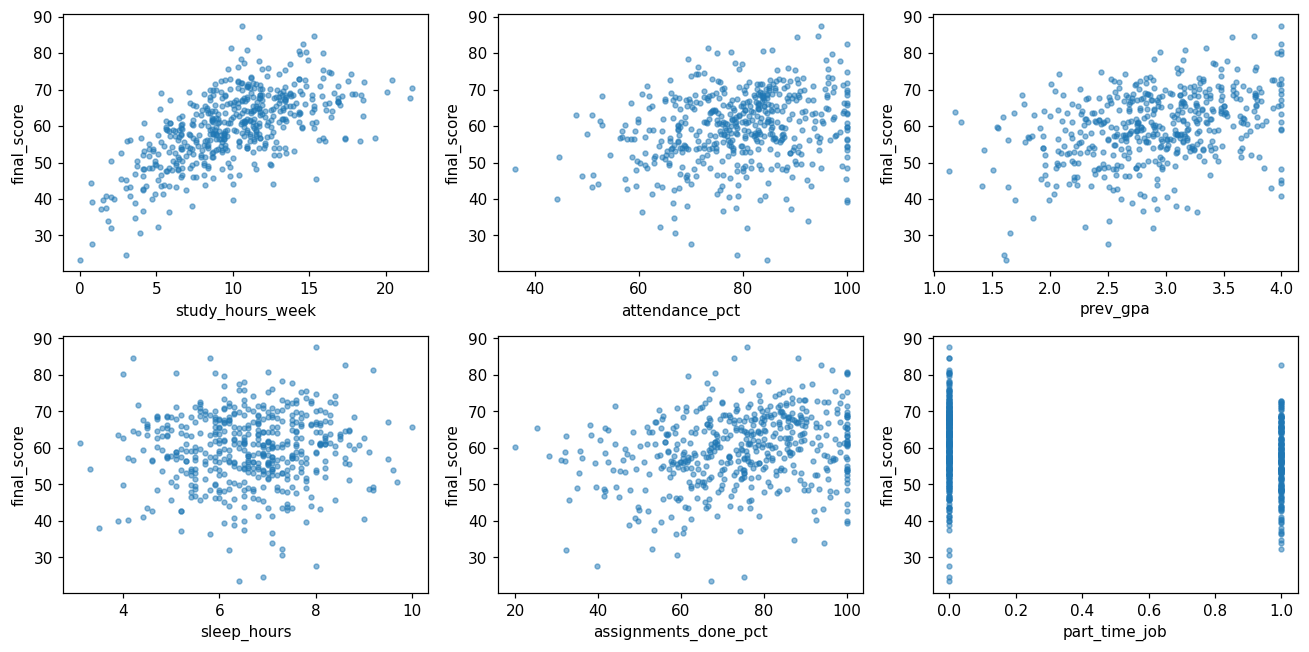

In [36]:
num_cols = ["study_hours_week", "attendance_pct", "prev_gpa", "sleep_hours",
            "assignments_done_pct", "part_time_job"]

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, col in zip(axes.ravel(), num_cols):
    ax.scatter(df[col], df["final_score"], s=10, alpha=.5)
    ax.set_xlabel(col); ax.set_ylabel("final_score")
plt.tight_layout(); plt.show()

# the effect of each feature on final_score :

##train and test data :

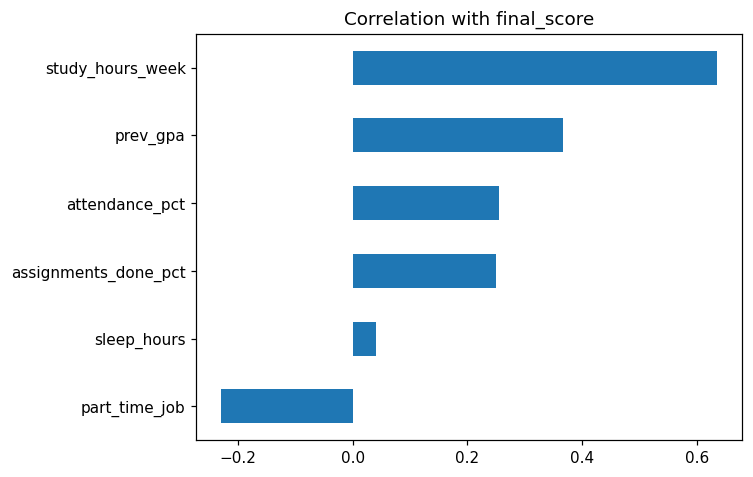

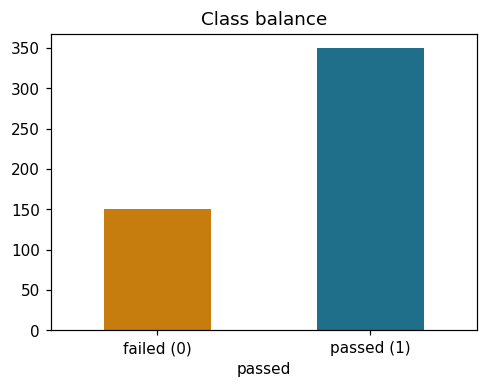

In [37]:
corr = df[num_cols + ["final_score"]].corr()["final_score"].drop("final_score").sort_values()
corr.plot.barh(title="Correlation with final_score")
plt.show()

plt.figure(figsize=(5, 3.5))
df["passed"].value_counts().sort_index().plot.bar(color=["#C77C0E", "#1F6F8B"])
plt.xticks([0, 1], ["failed (0)", "passed (1)"], rotation=0); plt.title("Class balance"); plt.show()

**What I see**
- `study_hours_week` has the strongest link with the score, and the cloud bends: extra hours help less and less (diminishing returns). That is the hint for the polynomial model.
- `prev_gpa` is next, then `attendance_pct`, `assignments_done_pct` and `part_time_job` (negative). `sleep_hours` is almost flat.
- About 70% pass and 30% fail, so the classes are imbalanced.


## 2. Missing values: how I handle them

`prev_gpa` and `sleep_hours` have a few missing values. I fill them with the **median** of the training data, using a `SimpleImputer` inside every pipeline.

- Median is safe because it is not pulled by outliers.
- Dropping rows would throw away data (about 6% of rows) for no reason.
- The imputer sits **inside the pipeline**, so it is fitted on training data only, and inside each cross-validation fold it is fitted on that fold's training part only. No information leaks from the test set or the validation folds.

#LR Model :

##  Split once:

One split, fixed `random_state`, used for **both** parts. I stratify on `passed` so train and test both keep the same 70/30 mix. The test set is touched only at the end.

In [38]:
features = num_cols                # student_id is just a label; final_score and passed are targets
X = df[features]
y_score = df["final_score"]        # Part A target
y_pass = df["passed"]              # Part B target

X_train, X_test, ys_train, ys_test, yp_train, yp_test = train_test_split(
    X, y_score, y_pass, test_size=0.2, random_state=RANDOM_STATE, stratify=y_pass)

print("train:", X_train.shape, " test:", X_test.shape)
print("pass rate train / test:", round(yp_train.mean(), 3), "/", round(yp_test.mean(), 3))

train: (400, 6)  test: (100, 6)
pass rate train / test: 0.7 / 0.7


In [39]:
def imputer():
    # keeps column names so ColumnTransformer can pick columns by name
    return SimpleImputer(strategy="median").set_output(transform="pandas")

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)             # for regression
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)  # for classification

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

### A1. Linear regression on all features

In [40]:
lin = Pipeline([("imp", imputer()), ("scale", StandardScaler()), ("model", LinearRegression())])
lin.fit(X_train, ys_train)
pred_lin = lin.predict(X_test)

coefs = pd.Series(lin.named_steps["model"].coef_, index=features).sort_values()
print("Coefficients (per 1 standard deviation of each feature):")
print(coefs.round(2))
print("\nTest RMSE:", round(rmse(ys_test, pred_lin), 3), " R2:", round(r2_score(ys_test, pred_lin), 3))

Coefficients (per 1 standard deviation of each feature):
part_time_job          -2.25
sleep_hours             0.94
assignments_done_pct    1.96
attendance_pct          2.49
prev_gpa                3.44
study_hours_week        6.01
dtype: float64

Test RMSE: 5.46  R2: 0.713


### A2. Polynomial regression, degree chosen by 5-fold CV

Plot first: does the 20th hour of study help as much as the 2nd? The scatter above says no. So I add polynomial terms for `study_hours_week` and keep the other features linear. (Making *every* feature polynomial is tested in A3.)

 degree  train RMSE  CV RMSE
      1       5.544    5.678
      2       4.938    5.022
      3       4.931    5.025
      4       4.926    5.026
      5       4.919    5.033
      6       4.918    5.040

Best degree: {'cols__hours__poly__degree': 2}


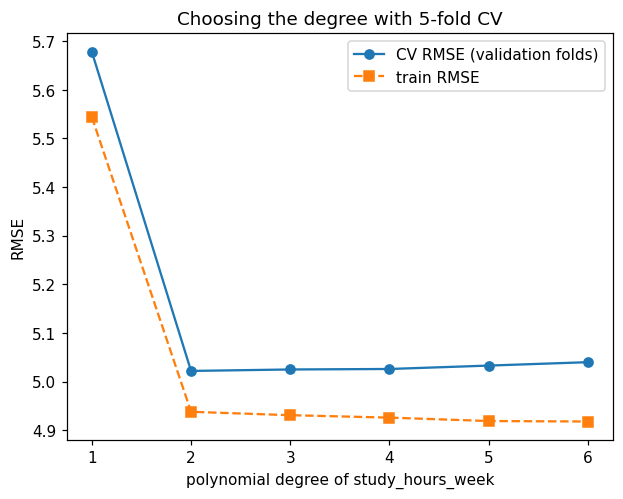

In [41]:
poly_hours = Pipeline([("poly", PolynomialFeatures(include_bias=False)), ("scale", StandardScaler())])

poly_model = Pipeline([
    ("imp", imputer()),
    ("cols", ColumnTransformer([("hours", poly_hours, ["study_hours_week"])],
                               remainder=StandardScaler())),
    ("model", LinearRegression()),
])

grid_poly = GridSearchCV(poly_model, {"cols__hours__poly__degree": [1, 2, 3, 4, 5, 6]},
                         cv=kf, scoring="neg_root_mean_squared_error", return_train_score=True)
grid_poly.fit(X_train, ys_train)

res = pd.DataFrame({
    "degree": [1, 2, 3, 4, 5, 6],
    "train RMSE": -grid_poly.cv_results_["mean_train_score"],
    "CV RMSE": -grid_poly.cv_results_["mean_test_score"],
}).round(3)
print(res.to_string(index=False))
print("\nBest degree:", grid_poly.best_params_)

plt.plot(res["degree"], res["CV RMSE"], "o-", label="CV RMSE (validation folds)")
plt.plot(res["degree"], res["train RMSE"], "s--", label="train RMSE")
plt.xlabel("polynomial degree of study_hours_week"); plt.ylabel("RMSE"); plt.legend()
plt.title("Choosing the degree with 5-fold CV"); plt.show()

In [43]:
pred_poly = grid_poly.predict(X_test)
print("Test RMSE:", round(rmse(ys_test, pred_poly), 3), " R2:", round(r2_score(ys_test, pred_poly), 3))

Test RMSE: 4.914  R2: 0.767


### A3. Check: polynomial terms on *all* features

This adds squares and interactions of every feature. With only 400 training rows, a high degree should overfit. CV decides.

In [44]:
poly_all = Pipeline([
    ("imp", imputer()), ("scale", StandardScaler()),
    ("poly", PolynomialFeatures(include_bias=False)), ("scale2", StandardScaler()),
    ("model", LinearRegression()),
])
grid_all = GridSearchCV(poly_all, {"poly__degree": [1, 2, 3]}, cv=kf,
                        scoring="neg_root_mean_squared_error")
grid_all.fit(X_train, ys_train)
print(pd.DataFrame({"degree": [1, 2, 3], "CV RMSE": -grid_all.cv_results_["mean_test_score"]}).round(3).to_string(index=False))
print("Best:", grid_all.best_params_)
pred_all = grid_all.predict(X_test)
print("Test RMSE:", round(rmse(ys_test, pred_all), 3), " R2:", round(r2_score(ys_test, pred_all), 3))

 degree  CV RMSE
      1    5.678
      2    5.236
      3    6.002
Best: {'poly__degree': 2}
Test RMSE: 5.077  R2: 0.752


### A4. Part A results

In [45]:
results_a = pd.DataFrame({
    "Model": ["Linear (all features)",
              f"Poly study_hours (degree {grid_poly.best_params_['cols__hours__poly__degree']}) + linear rest",
              f"Poly all features (degree {grid_all.best_params_['poly__degree']})"],
    "Test RMSE": [rmse(ys_test, p) for p in (pred_lin, pred_poly, pred_all)],
    "Test R2": [r2_score(ys_test, p) for p in (pred_lin, pred_poly, pred_all)],
}).round(3)
results_a

,Model,Test RMSE,Test R2
0,Linear (all features),5.460,0.713
1,Poly study_hours (degree 2) + linear rest,4.914,0.767
2,Poly all features (degree 2),5.077,0.752


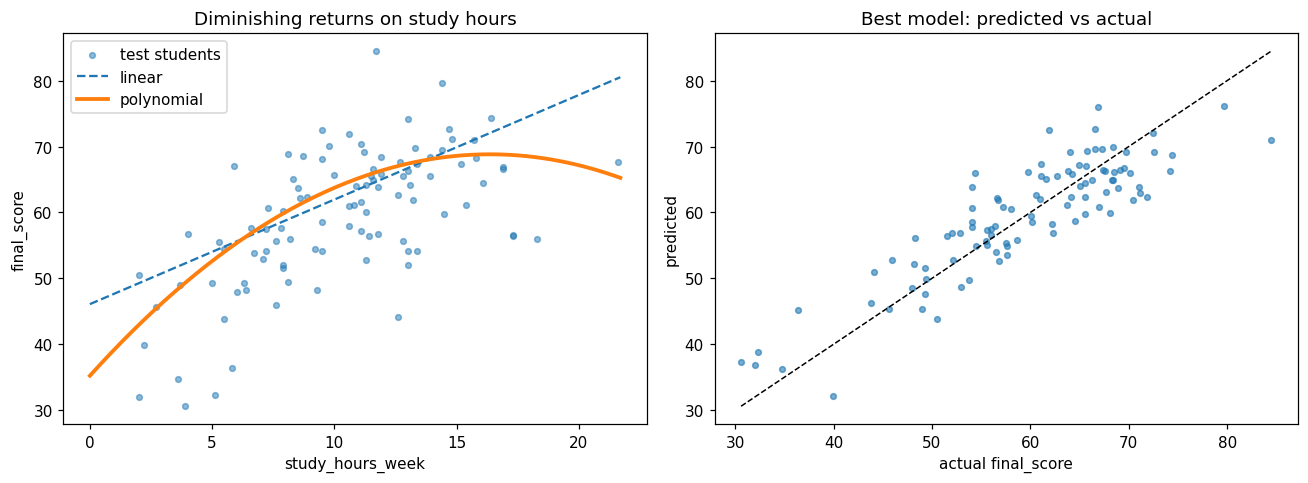

In [46]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

# left: study hours curve (other features held at their typical values)
grid_x = np.linspace(X["study_hours_week"].min(), X["study_hours_week"].max(), 200)
typical = X_train.median()
curve_df = pd.DataFrame([typical] * 200).reset_index(drop=True)
curve_df["study_hours_week"] = grid_x
ax[0].scatter(X_test["study_hours_week"], ys_test, s=14, alpha=.5, label="test students")
ax[0].plot(grid_x, lin.predict(curve_df), "--", label="linear")
ax[0].plot(grid_x, grid_poly.predict(curve_df), lw=2.5, label="polynomial")
ax[0].set_xlabel("study_hours_week"); ax[0].set_ylabel("final_score"); ax[0].legend()
ax[0].set_title("Diminishing returns on study hours")

# right: predicted vs actual
ax[1].scatter(ys_test, pred_poly, s=14, alpha=.6)
lims = [ys_test.min(), ys_test.max()]
ax[1].plot(lims, lims, "k--", lw=1)
ax[1].set_xlabel("actual final_score"); ax[1].set_ylabel("predicted"); ax[1].set_title("Best model: predicted vs actual")
plt.tight_layout(); plt.show()

# Part B: predict `passed` (classification)

In [47]:
def evaluate(name, fitted, X_te, y_te):
    pred = fitted.predict(X_te)
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_te, pred),
        "Precision": precision_score(y_te, pred),
        "Recall": recall_score(y_te, pred),
        "F1": f1_score(y_te, pred),
        "Recall (fail class)": recall_score(y_te, pred, pos_label=0),
    }

baseline = max(yp_test.mean(), 1 - yp_test.mean())
print("Accuracy of always predicting 'pass':", round(baseline, 3))

Accuracy of always predicting 'pass': 0.7


### B1. Logistic regression (tune C)

In [48]:
log_pipe = Pipeline([("imp", imputer()), ("scale", StandardScaler()),
                     ("model", LogisticRegression(max_iter=1000))])
grid_log = GridSearchCV(log_pipe, {"model__C": [0.001, 0.01, 0.1, 1, 10, 100]},
                        cv=skf, scoring="f1").fit(X_train, yp_train)
print("Best:", grid_log.best_params_, " CV F1:", round(grid_log.best_score_, 3))

Best: {'model__C': 1}  CV F1: 0.896


### B2. K-nearest neighbors (tune k)

KNN decides by **distance**. Without scaling, a feature with big numbers (`attendance_pct`, 0 to 100) would drown out a small one (`prev_gpa`, 1 to 4, or `part_time_job`, 0 or 1), even if the small one matters more. Scaling gives each feature a fair vote. The check below shows the effect.

Best: {'model__n_neighbors': 5}  CV F1: 0.875
Without scaling, best CV F1: 0.836


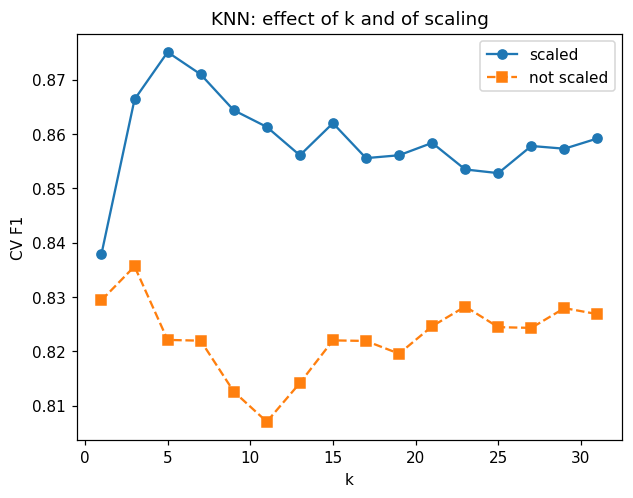

In [49]:
knn_pipe = Pipeline([("imp", imputer()), ("scale", StandardScaler()),
                     ("model", KNeighborsClassifier())])
grid_knn = GridSearchCV(knn_pipe, {"model__n_neighbors": list(range(1, 32, 2))},
                        cv=skf, scoring="f1").fit(X_train, yp_train)
print("Best:", grid_knn.best_params_, " CV F1:", round(grid_knn.best_score_, 3))

# same search WITHOUT scaling, just to show why scaling matters
knn_noscale = Pipeline([("imp", imputer()), ("model", KNeighborsClassifier())])
grid_noscale = GridSearchCV(knn_noscale, {"model__n_neighbors": list(range(1, 32, 2))},
                            cv=skf, scoring="f1").fit(X_train, yp_train)
print("Without scaling, best CV F1:", round(grid_noscale.best_score_, 3))

ks = list(range(1, 32, 2))
plt.plot(ks, grid_knn.cv_results_["mean_test_score"], "o-", label="scaled")
plt.plot(ks, grid_noscale.cv_results_["mean_test_score"], "s--", label="not scaled")
plt.xlabel("k"); plt.ylabel("CV F1"); plt.legend(); plt.title("KNN: effect of k and of scaling"); plt.show()

### B3. Decision tree (tune max_depth)

Best: {'model__max_depth': 3}  CV F1: 0.871


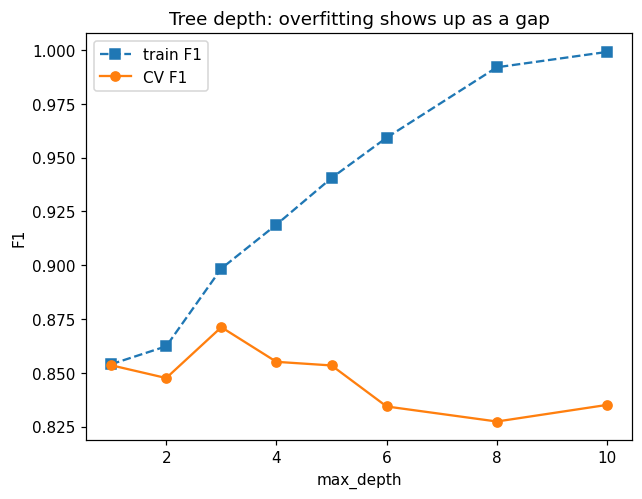

In [50]:
tree_pipe = Pipeline([("imp", imputer()), ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))])
depths = [1, 2, 3, 4, 5, 6, 8, 10]
grid_tree = GridSearchCV(tree_pipe, {"model__max_depth": depths},
                         cv=skf, scoring="f1", return_train_score=True).fit(X_train, yp_train)
print("Best:", grid_tree.best_params_, " CV F1:", round(grid_tree.best_score_, 3))

plt.plot(depths, grid_tree.cv_results_["mean_train_score"], "s--", label="train F1")
plt.plot(depths, grid_tree.cv_results_["mean_test_score"], "o-", label="CV F1")
plt.xlabel("max_depth"); plt.ylabel("F1"); plt.legend(); plt.title("Tree depth: overfitting shows up as a gap"); plt.show()

##Decision Tree :

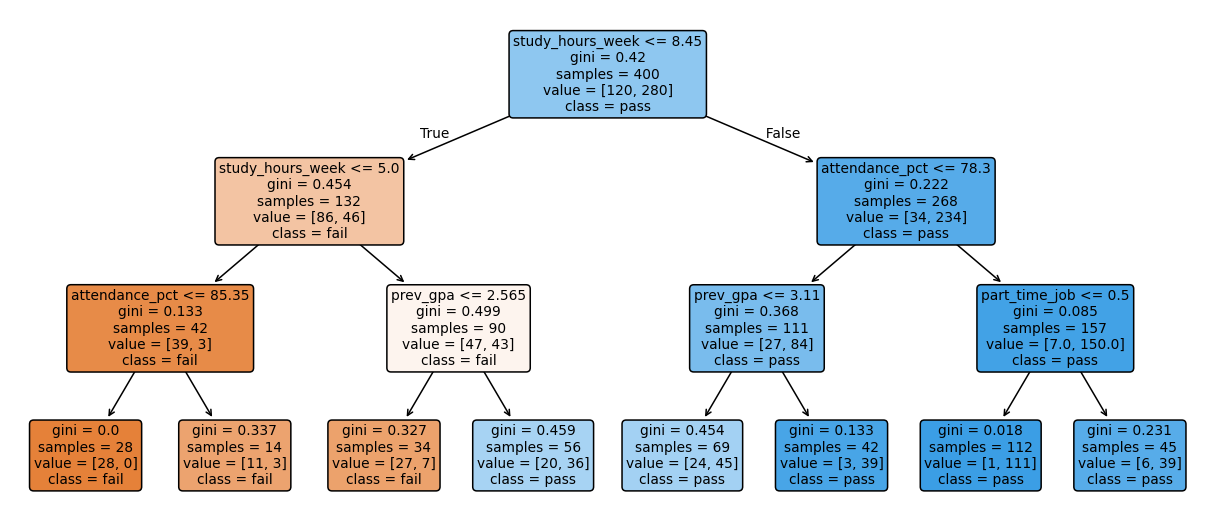

Top split: study_hours_week <= 8.45

study_hours_week        0.753
prev_gpa                0.156
attendance_pct          0.078
part_time_job           0.013
sleep_hours             0.000
assignments_done_pct    0.000
dtype: float64


In [53]:
best_tree = grid_tree.best_estimator_.named_steps["model"]
plt.figure(figsize=(14, 6))
plot_tree(best_tree, feature_names=features, class_names=["fail", "pass"],
          filled=True, rounded=True, fontsize=9)
plt.show()

root_feature = features[best_tree.tree_.feature[0]]
root_threshold = best_tree.tree_.threshold[0]
print(f"Top split: {root_feature} <= {root_threshold:.2f}")
print()
print(pd.Series(best_tree.feature_importances_, index=features).sort_values(ascending=False).round(3))

### B4. Test-set results

In [54]:
models_b = {"Logistic regression": grid_log, "KNN": grid_knn, "Decision tree": grid_tree}
results_b = pd.DataFrame([evaluate(n, m, X_test, yp_test) for n, m in models_b.items()]).round(3)
results_b

,Model,Accuracy,Precision,Recall,F1,Recall (fail class)
0,Logistic regression,0.85,0.867,0.929,0.897,0.667
1,KNN,0.80,0.821,0.914,0.865,0.533
2,Decision tree,0.82,0.802,0.986,0.885,0.433


## confusion Matrix of the results :

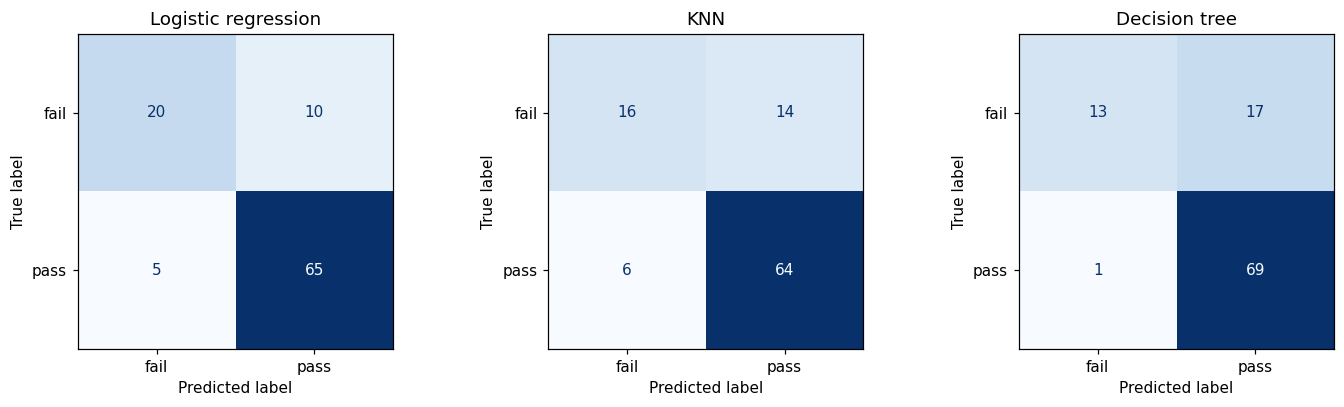

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (name, m) in zip(axes, models_b.items()):
    ConfusionMatrixDisplay.from_predictions(yp_test, m.predict(X_test), display_labels=["fail", "pass"],
                                            cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(name)
plt.tight_layout(); plt.show()

**Why accuracy alone can mislead.** With 70% passing, "everyone passes" scores 70% accuracy while catching **zero** failing students. A model can look good on accuracy and still miss many students who need help. That is why I look at precision, recall (especially for the fail class), F1 and the confusion matrix.

In [56]:
final = pd.DataFrame({
    "Task": ["Regression"] * 3 + ["Classification"] * 3,
    "Model": list(results_a["Model"]) + list(results_b["Model"]),
    "Main metrics": [f"RMSE {r:.2f}, R2 {s:.3f}" for r, s in zip(results_a["Test RMSE"], results_a["Test R2"])]
                    + [f"Acc {a:.3f}, F1 {f:.3f}, fail-recall {fr:.3f}"
                       for a, f, fr in zip(results_b["Accuracy"], results_b["F1"], results_b["Recall (fail class)"])],
})
final

,Task,Model,Main metrics
0,Regression,Linear (all features),"RMSE 5.46, R2 0.713"
1,Regression,Poly study_hours (degree 2) + linear rest,"RMSE 4.91, R2 0.767"
2,Regression,Poly all features (degree 2),"RMSE 5.08, R2 0.752"
3,Classification,Logistic regression,"Acc 0.850, F1 0.897, fail-recall 0.667"
4,Classification,KNN,"Acc 0.800, F1 0.865, fail-recall 0.533"
5,Classification,Decision tree,"Acc 0.820, F1 0.885, fail-recall 0.433"
